# SG&A Cost Stickiness — a quantitative teardown 🔬
### A point-in-time ABJ estimator · a calendar-time tercile long-short (Newey-West) · a pooled event-drift cross-check with a label-shuffle placebo · an era split · a future-ROA regression · a 10-seed synthetic control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Sticky costs%3F: Confirmed](https://img.shields.io/badge/Sticky_costs%3F-Confirmed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim — **sticky-cost firms under-earn** — rests on a real phenomenon (Anderson-Banker-Janakiraman cost stickiness) and a leap (that a firm's cost-cut elasticity sorts its stock). We confirm the phenomenon and reject the leap. This is distinct from every sibling: [524](../../524-operating-leverage/) is the cost elasticity's *magnitude*, [200](../../200-roe-quality/) / [122](../../122-gross-profitability/) are profitability *levels*, [749](../../749-layoff-drift/) is a cost-cut *event*.

> ⚠️ **Data note.** EDGAR `SellingGeneralAndAdministrativeExpense` + revenue (quarterly) + net income + assets, 33 names (25 identify β₂), ends 2015-09-26 → 2026-05-03, as-of 2026-06-30. Stickiness estimated **point-in-time on an expanding window** of only-public filings. Survivorship named on the Signal axis (current survivors — the bias runs *against* the claim). Thin/cyclical/noisy coverage is a first-class caveat. Numbers in [`docs/results.md`](../docs/results.md) (prices fingerprint `2cf202cb4854`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from sga_stickiness import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PX, EV = data.load_real()
else:
    PX = EV = None
print("real cache present:", HAVE_REAL, "| events:", (0 if EV is None else len(EV)),
      "| names:", (0 if EV is None else EV['ticker'].nunique()))

# frozen headline numbers (mirror of docs/results.md)
R = {'as_of': '2026-06-30', 'n_names': 33, 'n_ident': 25, 'n_events': 314, 'end_lo': '2015-09-26', 'end_hi': '2026-05-03', 'fp_prices': '2cf202cb4854', 'abj_b1': 0.651, 'abj_b1p2': 0.554, 'abj_b2': -0.097, 'n_sticky': 12, 'n_total': 25, 'n_months': 101, 'avg_n': 11.0, 'ls_span_lo': '2015-12-31', 'ls_span_hi': '2026-06-30', 'ls_mean_bps': -28.6, 'ls_ann': -3.43, 'ls_t_iid': -0.57, 'ls_t_nw': -0.45, 'ls_sharpe': -0.2, 'ls_hit': 48, 'ls_long_bps': 125.2, 'ls_short_bps': 153.7, 'ls_turn': 0.07, 'ls_cum': 0.66, 'ls120_mean_bps': 28.1, 'ls120_t_nw': 0.66, 'drift': {21: (313, 1.37, 1.72, -0.35, -0.32, 50, 0.6233), 63: (301, 5.92, 4.65, 1.27, 0.57, 54, 0.2546), 126: (296, 10.77, 11.52, -0.76, -0.24, 54, 0.5872)}, 'mono63': (4.65, 4.85, 5.92), 'era_early_n': 54, 'era_early_bps': 14.4, 'era_early_t': 0.2, 'era_late_n': 47, 'era_late_bps': -78.0, 'era_late_t': -0.74, 'roa_n': 226, 'roa_slope': 0.0004, 'roa_t': 0.15, 'roa_r2': 0.0, 'roa_corr': 0.01, 'roa_top': 0.34, 'roa_bot': 0.48, 'roa_spread': -0.14, 'net': {(10, 50): (-34.1, -4.1, -0.54, -0.23), (20, 100): (-39.7, -4.77, -0.63, -0.27)}, 'syn_null_mean': 0.02, 'syn_null_sd': 0.87, 'syn_null_fire': 0, 'syn_null_seeds': 10, 'syn_planted_bps': 156.9, 'syn_planted_t': 3.16}


real cache present: True | events: 314 | names: 25


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** (returns) | `NONE` | calendar tercile long-short **-28.6 bps/mo** (-3.4%/yr gross), one-sample *t* = -0.57, **Newey-West *t* = -0.45** — wrong sign, sign-unstable (staleness-120 → +0.66) |
| **Tradability** | `MIRAGE` | net of 20 bps + 100 bps borrow: NW *t* = -0.63, Sharpe -0.27; wrong sign before costs |
| **Is SG&A sticky?** | `CONFIRMED` | pooled β₁ = +0.65 vs β₁+β₂ = +0.55 (β₂ = -0.10); future-ROA slope +0.0004 (corr +0.01), tercile spread -0.14 pp |

> 💡 In plain words: the accounting regularity is genuine and the return/profit edge is a two-sided null. A public cost elasticity describes how costs behave, and the market neither rewards nor punishes the firms that let them stick.

## 1 · The claim, steelmanned

For firm $i$ at quarter $q$, regress the point-in-time year-over-year log changes on an expanding public window,

$$\Delta\log SGA_{i,q} = \beta_0 + \beta_1\,\Delta\log Sales_{i,q} + \beta_2\,(D_{i,q}\cdot\Delta\log Sales_{i,q}) + \varepsilon,$$

with $D=1$ when sales fell YoY. $\beta_1$ is the up-response, $\beta_1+\beta_2$ the down-response, and **stickiness $= -\beta_2$**. We trade $disc_{i,q}=\beta_2$ (= $-$stickiness; higher ⇒ leaner). The claims:

- **H₁ (stickiness exists).** $\beta_2 < 0$ on average — costs are sticky.
- **H₂ (sticky firms under-earn).** A long-lean / short-sticky spread on $disc$ is positive.
- **H₃ (weaker operating results).** Higher stickiness ⇒ weaker future ROA.
- **H₄ (tradable).** Any H₂ spread survives costs + borrow.

We find **H₁ confirmed** (pooled β₁ = +0.65 vs β₁+β₂ = +0.55), **H₂ rejected** (NW *t* = -0.45, wrong sign, sign-unstable), **H₃ rejected** (ROA slope +0.0004, corr +0.01), and therefore **H₄ moot**. Note H₂ is `NONE`, not `WEAK`: there is no consistent right-signed whiff to certify — the point estimates straddle zero.

## 2 · So what? — inference design

The primary is a **calendar-time** long-short, not a pooled event study, because a firm-level characteristic is persistent and filings cluster: a monthly long-short series lets a **Newey-West (6-lag) HAC *t*** do the honest work the desk's `REAL` bar is written against. The panel is thin, so we sort into **terciles** (not quintiles) and require ≥ 6 names. The pooled event drift + a **label-shuffle placebo** is the cross-check; the future-ROA regression is graded on **magnitude** (its pooled *t* ignores firm/quarter clustering). Crucially, β₂ is estimated **point-in-time** — the expanding window at each filing uses only prior public data, so the signal never peeks at its own future.

## 3 · How we'd know — the protocol

- **Panel.** 314 (ticker, filing) stickiness estimates across 25 names that identify β₂ (of 33 in the basket), ends 2015-09-26 → 2026-05-03, each stamped with its 10-Q/10-K filing date.
- **Estimator.** ABJ asymmetric regression on an expanding window of public quarterly YoY changes; guards: ≥20 obs, ≥4 decline quarters (β₂ must be identified).
- **Primary.** Monthly tercile long-short on `disc`, one execution lag; Newey-West + one-sample *t*, Sharpe, hit rate.
- **Cross-check.** Pooled event drift over 21/63/126 trading days, one-day-lag entry, one-sample *t* + label-shuffle placebo, tercile monotonicity.
- **Robustness.** Staleness 120 vs 200 days; an era split at the 2020 sales shock.
- **Mechanism.** Pooled OLS of next-year ROA change on stickiness.
- **Execution.** Long-short net of one-way cost × turnover (both legs) + short borrow.
- **Control.** Synthetic SG&A/sales levels through the *same* estimator; the null must not fire across 10 seeds.

## 4 · The teardown

### 4a · The phenomenon — is SG&A actually sticky? (ABJ replication)

Pooled across all firm-quarter estimates, the average up-response vs down-response.

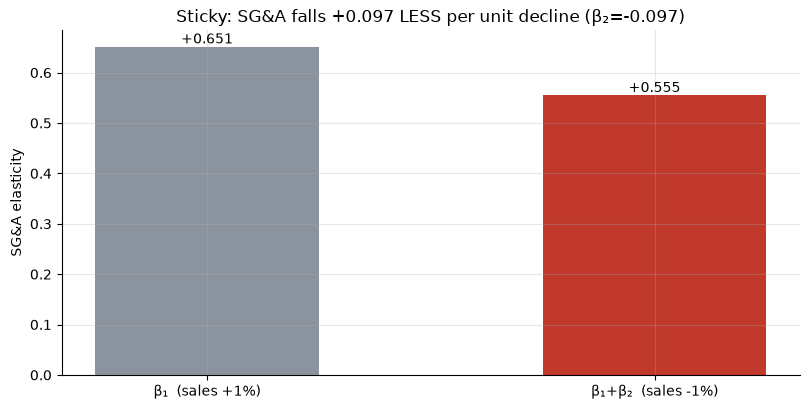

pooled ABJ: β₁=+0.651 (up), β₁+β₂=+0.555 (down), asymmetry β₂=-0.097
12 of 25 names estimate as sticky (final β₂<0)


In [2]:
if HAVE_REAL:
    b1, b2 = EV['beta1'].mean(), EV['beta2'].mean()
else:
    b1, b2 = R['abj_b1'], R['abj_b2']
up, dn = b1, b1 + b2
fig, ax = plt.subplots(figsize=(8.2, 4.2))
ax.bar(['β₁  (sales +1%)', 'β₁+β₂  (sales -1%)'], [up, dn], color=[GREY, RED], width=.5)
for i,v in enumerate([up, dn]): ax.annotate(f'{v:+.3f}',(i,v),ha='center',va='bottom')
ax.set_ylabel('SG&A elasticity'); ax.axhline(0,c='k',lw=.6)
ax.set_title(f'Sticky: SG&A falls {up-dn:+.3f} LESS per unit decline (β₂={b2:+.3f})')
plt.tight_layout(); plt.show()
print(f'pooled ABJ: β₁={b1:+.3f} (up), β₁+β₂={b1+b2:+.3f} (down), asymmetry β₂={b2:+.3f}')
print(f'{R["n_sticky"]} of {R["n_total"]} names estimate as sticky (final β₂<0)')

> 💡 In plain words: β₁ = +0.65 but β₁+β₂ = +0.55 — SG&A comes down **less** than it goes up. The ABJ effect is real on our tape (milder than the original 0.55/0.35 because we estimate at quarterly YoY frequency). The input phenomenon is not in doubt. Everything below asks whether it *sorts stocks*.

### 4b · The primary — calendar-time tercile long-short (Newey-West)

Rank fresh `disc` into terciles each month, long leanest / short stickiest, earn next month's return. The decisive statistic is the HAC *t* of the monthly series.

calendar long-short: -28.6 bps/mo (-3.43%/yr gross), n=101 months, avg cross-section 11.0
  one-sample t = -0.57   Newey-West(6) t = -0.45   Sharpe -0.20   hit 48%   turnover 0.07
  staleness-120 variant: +28.1 bps/mo, NW t = +0.66  (sign flips!)


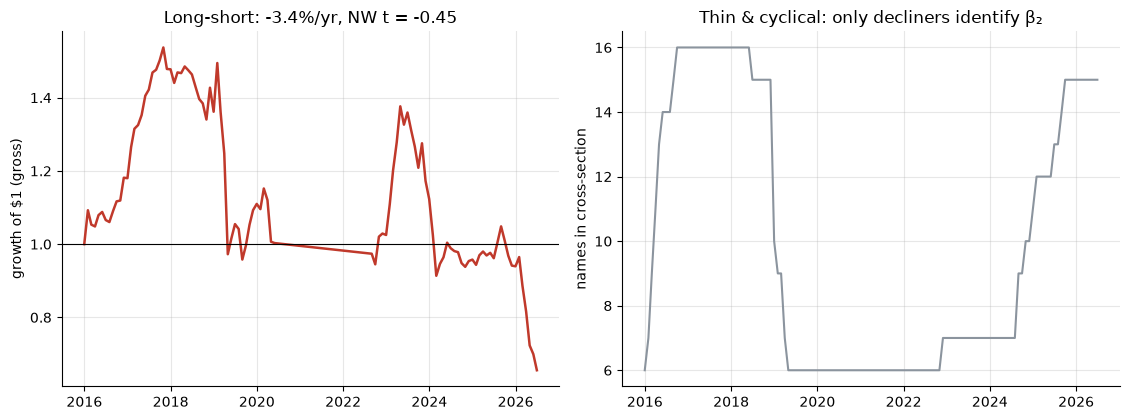

frozen: -28.6 bps/mo, NW t = -0.45, staleness-120 NW t = +0.66


In [3]:
if HAVE_REAL:
    ls = st.calendar_ls(PX, EV, signal_col='disc', n_buckets=3, min_names=6, staleness_days=200)
    s = st.calendar_ls_stats(ls)
    ls120 = st.calendar_ls(PX, EV, signal_col='disc', n_buckets=3, min_names=6, staleness_days=120)
    s120 = st.calendar_ls_stats(ls120)
    print(f"calendar long-short: {s['mean_bps']:+.1f} bps/mo ({s['ann_pct']:+.2f}%/yr gross), "
          f"n={s['n_months']} months, avg cross-section {s['avg_n']:.1f}")
    print(f"  one-sample t = {s['t_iid']:+.2f}   Newey-West(6) t = {s['t_nw']:+.2f}   "
          f"Sharpe {s['sharpe']:.2f}   hit {s['hit']*100:.0f}%   turnover {s['avg_turnover']:.2f}")
    print(f"  staleness-120 variant: {s120['mean_bps']:+.1f} bps/mo, NW t = {s120['t_nw']:+.2f}  (sign flips!)")
    cum = (1+ls['ls']).cumprod(); nser = ls['n']
else:
    cum = None; nser = None
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.4, 4.3))
if cum is not None:
    a1.plot(cum.index, cum.values, color=RED, lw=1.8); a1.axhline(1, c='k', lw=.8)
    a1.set_ylabel('growth of $1 (gross)'); a1.set_title(f"Long-short: {R['ls_ann']:+.1f}%/yr, NW t = {R['ls_t_nw']:+.2f}")
    a2.plot(nser.index, nser.values, color=GREY, lw=1.5); a2.set_ylabel('names in cross-section')
    a2.set_title('Thin & cyclical: only decliners identify β₂')
else:
    for a in (a1,a2): a.text(.5,.5,'run with cache',ha='center'); a.set_axis_off()
plt.tight_layout(); plt.show()
print(f"frozen: {R['ls_mean_bps']:+.1f} bps/mo, NW t = {R['ls_t_nw']:+.2f}, "
      f"staleness-120 NW t = {R['ls120_t_nw']:+.2f}")

> 💡 In plain words: **-29 bps/month** with a HAC *t* of **-0.45** — the wrong sign for the claim and statistically zero. The single most damning detail: nudge the staleness window from 200 to 120 days and the mean flips to **+28 bps** (*t* = +0.66). A real signal doesn't change sign when you jiggle a housekeeping parameter. n = 101 months, avg cross-section 11 — thin by construction.

### 4c · The cross-check — pooled event drift + placebo + monotonicity

Bucket all events by `disc`; top-minus-bottom forward drift with a label-shuffle null. If there were a sort, the terciles would form a ladder and the sign would hold.

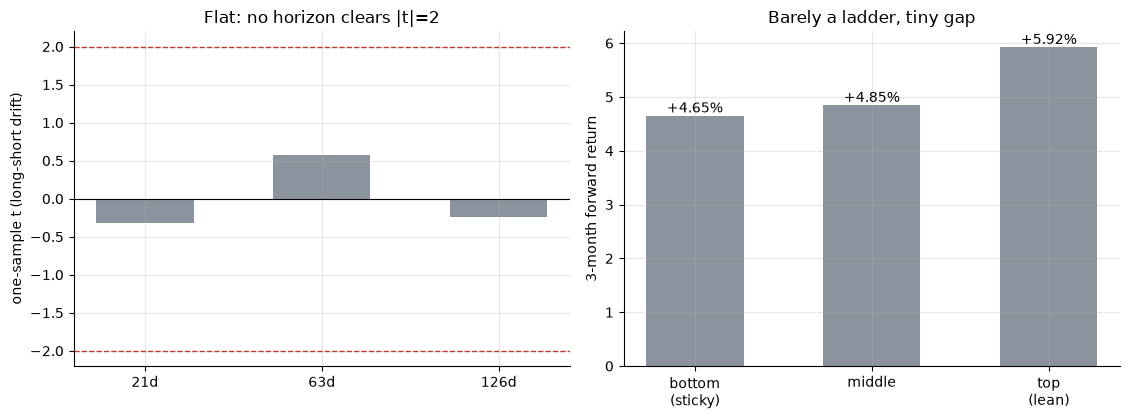

  H= 21d: long-short -0.35%  t=-0.32  win=50%  placebo p=0.629
  H= 63d: long-short +1.27%  t=+0.57  win=54%  placebo p=0.258
  H=126d: long-short -0.76%  t=-0.24  win=54%  placebo p=0.587


In [4]:
rows = []
if HAVE_REAL:
    for h in st.HORIZONS:
        es = st.event_summary(PX, EV, horizon=h, n_buckets=3, n_draws=4000)
        rows.append((h, es['ls_mean']*100, es['t'], es['ls_win']*100, es['p_placebo']))
    mono = st.bucket_means(st.event_drift_frame(PX, EV, horizon=63), 3)*100
else:
    for h in st.HORIZONS:
        d = R['drift'][h]; rows.append((h, d[3], d[4], d[5], d[6]))
    mono = np.array(R['mono63'])
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.4, 4.3))
hs = [r[0] for r in rows]; ts = [r[2] for r in rows]
a1.bar([f'{h}d' for h in hs], ts, color=GREY, width=.55)
a1.axhline(2, ls='--', c=RED, lw=1); a1.axhline(-2, ls='--', c=RED, lw=1); a1.axhline(0, c='k', lw=.8)
a1.set_ylabel('one-sample t (long-short drift)'); a1.set_title('Flat: no horizon clears |t|=2')
a2.bar(['bottom\n(sticky)','middle','top\n(lean)'], mono, color=GREY, width=.55)
for i,v in enumerate(mono): a2.annotate(f'{v:+.2f}%',(i,v),ha='center',va='bottom')
a2.set_ylabel('3-month forward return'); a2.set_title('Barely a ladder, tiny gap')
plt.tight_layout(); plt.show()
for h,ls_,t,win,p in rows:
    print(f'  H={h:>3}d: long-short {ls_:+.2f}%  t={t:+.2f}  win={win:.0f}%  placebo p={p:.3f}')

> 💡 In plain words: the pooled long-short drift **can't hold a sign** (-0.35% / +1.27% / -0.76% across 1m/1q/2q), the *t* never exceeds +0.57, and the label-shuffle placebo *p* runs **0.25-0.62** — a random tercile split routinely beats the real one. The 63-day terciles (+4.65% / +4.85% / +5.92%) lean the claim's way by a hair, but it's the only horizon that does. The event study and the calendar long-short agree: no return sort.

### 4d · Era split — nothing hiding in a regime (and the sign flips)

Split the calendar long-short at the 2020 sales shock.

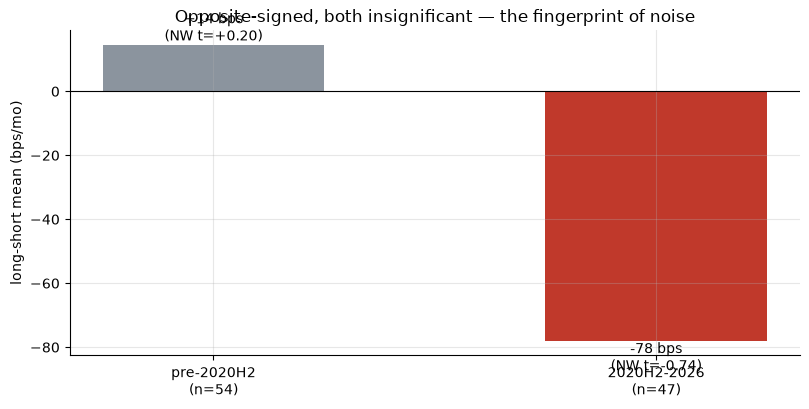

pre-2020H2: +14.4 bps NW t=+0.20 (n=54)  |  2020H2-2026: -78.0 bps NW t=-0.74 (n=47)


In [5]:
if HAVE_REAL:
    e = ls[ls.index < data.ERA_SPLIT]['ls'].to_numpy(); l = ls[ls.index >= data.ERA_SPLIT]['ls'].to_numpy()
    eb, et, en = e.mean()*1e4, st.newey_west_t(e), len(e)
    lb, lt, ln = l.mean()*1e4, st.newey_west_t(l), len(l)
else:
    eb, et, en = R['era_early_bps'], R['era_early_t'], R['era_early_n']
    lb, lt, ln = R['era_late_bps'], R['era_late_t'], R['era_late_n']
fig, ax = plt.subplots(figsize=(8.2, 4.2))
ax.bar([f'pre-2020H2\n(n={en})', f'2020H2-2026\n(n={ln})'], [eb, lb],
       color=[GREY, RED], width=.5)
for i,(v,t_) in enumerate([(eb,et),(lb,lt)]): ax.annotate(f'{v:+.0f} bps\n(NW t={t_:+.2f})',(i,v),ha='center',va='bottom' if v>=0 else 'top')
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('long-short mean (bps/mo)')
ax.set_title('Opposite-signed, both insignificant — the fingerprint of noise')
plt.tight_layout(); plt.show()
print(f'pre-2020H2: {eb:+.1f} bps NW t={et:+.2f} (n={en})  |  2020H2-2026: {lb:+.1f} bps NW t={lt:+.2f} (n={ln})')

> 💡 In plain words: +14 bps (NW *t* = +0.20) early, -78 bps (NW *t* = -0.74) late — **opposite signs**, both insignificant. Not a decayed edge; a coin that landed differently in each half.

### 4e · The mechanism check — does stickiness predict weaker profits?

Pooled OLS of the next-year change in trailing ROA on the stickiness measure, and the future-ROA-change spread between the stickiest and leanest terciles.

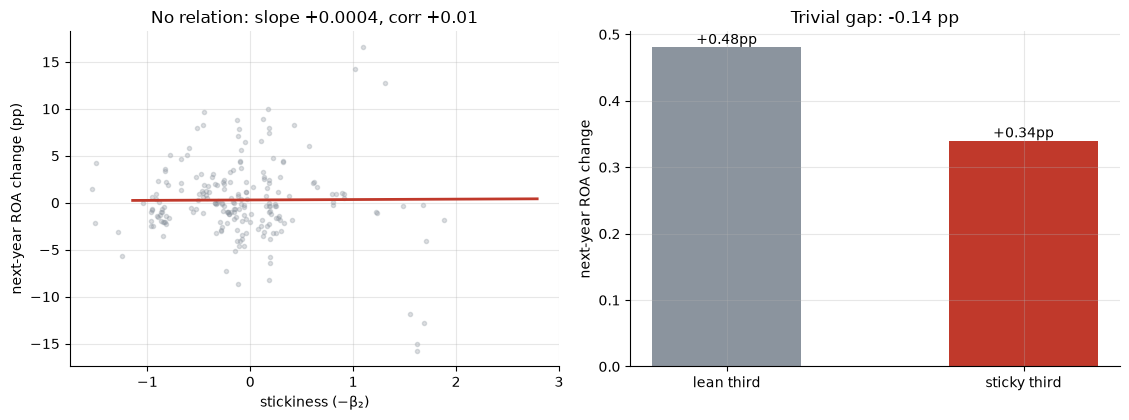

stickiness -> future ROA: slope +0.0004, corr +0.010, tercile spread -0.14 pp (sticky +0.34 vs lean +0.48)


In [6]:
if HAVE_REAL:
    q = st.predicts_profitability(EV)
    fr = EV.dropna(subset=['stickiness','roa_chg'])
    x, y = fr['stickiness'].to_numpy(), fr['roa_chg'].to_numpy()
    slope, corr, top, bot = q['slope'], q['corr'], q['top_roa_chg']*100, q['bot_roa_chg']*100
else:
    x = y = None
    slope, corr, top, bot = R['roa_slope'], R['roa_corr'], R['roa_top'], R['roa_bot']
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.4, 4.3))
if x is not None:
    m = (np.abs(x)<2)&(np.abs(y)<0.2)
    a1.scatter(x[m], y[m]*100, s=9, alpha=.3, color=GREY)
    xs = np.linspace(np.percentile(x,2), np.percentile(x,98), 50)
    a1.plot(xs, (q['slope']*xs + (y.mean()-q['slope']*x.mean()))*100, color=RED, lw=2)
    a1.set_xlabel('stickiness (−β₂)'); a1.set_ylabel('next-year ROA change (pp)')
    a1.set_title(f'No relation: slope {slope:+.4f}, corr {corr:+.2f}')
else:
    a1.text(.5,.5,'run with cache',ha='center'); a1.set_axis_off()
a2.bar(['lean third','sticky third'], [bot, top], color=[GREY, RED], width=.5)
for i,v in enumerate([bot, top]): a2.annotate(f'{v:+.2f}pp',(i,v),ha='center',va='bottom')
a2.set_ylabel('next-year ROA change'); a2.set_title(f'Trivial gap: {top-bot:+.2f} pp')
plt.tight_layout(); plt.show()
print(f'stickiness -> future ROA: slope {slope:+.4f}, corr {corr:+.3f}, tercile spread {top-bot:+.2f} pp (sticky {top:+.2f} vs lean {bot:+.2f})')

> 💡 In plain words: the 'weak discipline → weak earnings' mechanism **doesn't show up** either. The slope is +0.0004, the correlation +0.01, and the stickiest third's next-year ROA change is only -0.14 pp different from the leanest — directionally the claim's way, magnitudinally nothing. (A noisy quarterly β₂ attenuates any true relation; but a flat return null *and* a flat profit null is a consistent 'nothing here'.)

### 4f · Tradability — the timer

For completeness, the calendar long-short net of one-way costs × turnover (both legs) + short borrow — though a wrong-signed sub-1 gross *t* already settles it.

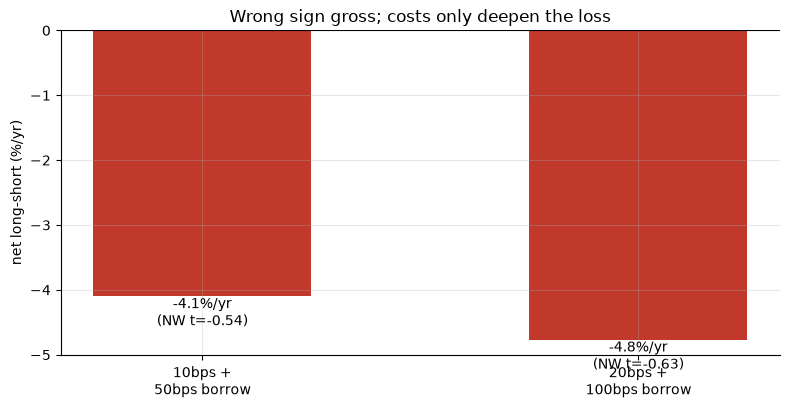

  cost 10bps + borrow 50bps/yr: -4.10%/yr net, NW t=-0.54, Sharpe -0.23
  cost 20bps + borrow 100bps/yr: -4.77%/yr net, NW t=-0.63, Sharpe -0.27


In [7]:
rows = []
if HAVE_REAL:
    for cb, bb in [(10.0,50.0),(20.0,100.0)]:
        nt = st.calendar_ls_net(ls, cost_bps=cb, borrow_bps_ann=bb)
        rows.append((cb, bb, nt['net_ann_pct'], nt['net_t_nw'], nt['net_sharpe']))
else:
    for (cb,bb),v in R['net'].items(): rows.append((cb, bb, v[1], v[2], v[3]))
labels = [f'{int(cb)}bps +\n{int(bb)}bps borrow' for cb,bb,_,_,_ in rows]
anns = [r[2] for r in rows]
fig, ax = plt.subplots(figsize=(8.0, 4.2))
ax.bar(labels, anns, color=[RED, RED], width=.5)
for i,(cb,bb,a,t,sh) in enumerate(rows): ax.annotate(f'{a:+.1f}%/yr\n(NW t={t:+.2f})',(i,a),ha='center',va='top')
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('net long-short (%/yr)')
ax.set_title('Wrong sign gross; costs only deepen the loss')
plt.tight_layout(); plt.show()
for cb,bb,a,t,sh in rows: print(f'  cost {int(cb)}bps + borrow {int(bb)}bps/yr: {a:+.2f}%/yr net, NW t={t:+.2f}, Sharpe {sh:.2f}')

> 💡 In plain words: net of 20 bps + 100 bps borrow the spread is -4.77%/yr, NW *t* = -0.63. There is no spread to pay costs on — it was the wrong sign and insignificant to begin with. **Tradability = MIRAGE.**

### 4g · Faithful-engine & power control

Synthetic SG&A + sales *levels* obeying a per-firm true β₂, pushed through the **same** estimator, with a TUNABLE planted forward-return link (lean names drift up). The null (edge = 0) is checked over **10 seeds**.

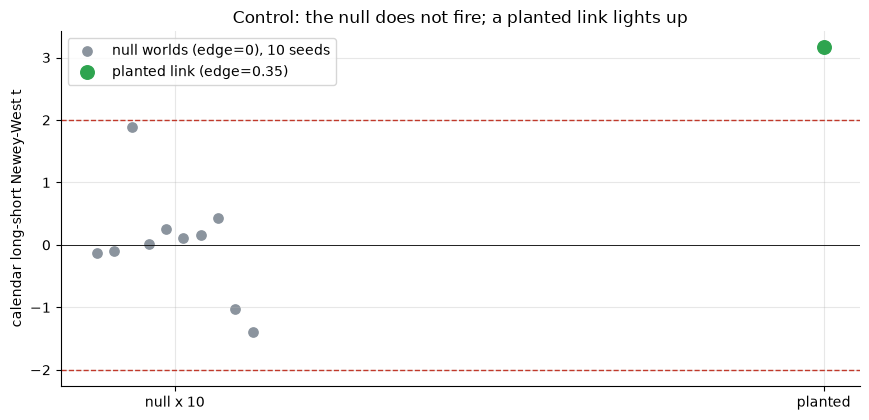

null: mean NW t = +0.02 (sd 0.87), |t|>=2 in 0/10  |  planted NW t = +3.16


In [8]:
null_ts = []
for s_ in range(10):
    p0, e0 = data.synthetic_panel(edge=0.0, seed=857 + s_)
    null_ts.append(st.synthetic_detect(p0, e0)['t_nw'])
null_ts = np.asarray(null_ts)
p1, e1 = data.synthetic_panel(edge=0.35, seed=857)
planted_t = st.synthetic_detect(p1, e1)['t_nw']
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.scatter(np.linspace(-.12,.12,10), null_ts, color=GREY, s=45, label='null worlds (edge=0), 10 seeds')
ax.scatter([1], [planted_t], color=GREEN, s=95, zorder=5, label='planted link (edge=0.35)')
ax.axhline(2, ls='--', c=RED, lw=1); ax.axhline(-2, ls='--', c=RED, lw=1); ax.axhline(0, c='k', lw=.6)
ax.set_xticks([0,1]); ax.set_xticklabels(['null x 10','planted'])
ax.set_ylabel('calendar long-short Newey-West t')
ax.set_title('Control: the null does not fire; a planted link lights up'); ax.legend()
plt.tight_layout(); plt.show()
print(f'null: mean NW t = {null_ts.mean():+.2f} (sd {null_ts.std(ddof=1):.2f}), '
      f'|t|>=2 in {(abs(null_ts)>=2).sum()}/10  |  planted NW t = {planted_t:+.2f}')

> 💡 In plain words: across 10 null worlds the detector averages NW *t* = +0.02 (sd 0.87) and crosses |t|=2 **0/10** times; a planted link reads NW *t* = 3.16. The machinery — including the point-in-time ABJ estimator — is unbiased and powered, so the real-tape -0.45 is a genuine null, not a broken pipeline. *(Power check only — never cited in support of a real-tape stamp.)*

## 5 · The verdict

- **Signal (returns) `NONE`** — calendar tercile long-short -28.6 bps/mo (-3.4%/yr gross), one-sample *t* = -0.57, **Newey-West *t* = -0.45** (wrong sign), sign-unstable (staleness-120 → +0.66); event drift flat and sign-inconsistent (placebo *p* ≈ 0.25-0.62); eras opposite-signed. No robust effect either way.
- **Tradability `MIRAGE`** — net of 20 bps + 100 bps borrow: -4.77%/yr, NW *t* = -0.63, Sharpe -0.27; wrong sign before costs.
- **Is SG&A sticky? `CONFIRMED`** — pooled β₁ = +0.65 vs β₁+β₂ = +0.55 (β₂ = -0.10). The ABJ phenomenon is real; it just neither sorts returns nor forecasts weaker ROA (spread -0.14 pp, corr +0.01).

## 6 · Going further

- **The residual worth chasing** is the *surprise*, not the *level*: a firm that suddenly stops cutting when the market expects discipline, or stickiness interacted with leverage / a live downturn. A decade-old public cost elasticity that forecasts neither the stock nor next year's ROA is the textbook signature of an already-priced (or simply non-predictive) fundamental.
- **Coverage honesty:** only firms that *decline* identify β₂, so the panel is thin (25 of 33 names), cyclical-tilted, and the quarterly firm-level β₂ is noisy — attenuation is a real caveat, but a flat return null *and* a flat profit null point the same way.
- **Dedup map:** [524-operating-leverage](../../524-operating-leverage/) (cost elasticity *magnitude*), [200-roe-quality](../../200-roe-quality/) & [122-gross-profitability](../../122-gross-profitability/) (profitability *levels*), [749-layoff-drift](../../749-layoff-drift/) (an announced cost-cut *event*). None estimates the asymmetric SG&A response itself.

*The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*